# Module 4 - Machine Learning Fundamentals

## House Price Prediction Using Machine Learning

### Objective

The objective of this project is to build a Machine Learning model that predicts house prices based on different features such as area, number of bedrooms, bathrooms, and house age.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

### Machine Learning Algorithm

Linear Regression

## 1. Introduction to Machine Learning

Machine Learning is a branch of Artificial Intelligence that enables computers to learn patterns from data and make predictions without being explicitly programmed for every situation.

In this project, we use Supervised Learning because the dataset contains input features and a known target value, which is the house price.

## 2. Machine Learning Workflow

The Machine Learning workflow used in this project is:

1. Collect or load the dataset
2. Understand the dataset
3. Clean the data
4. Explore the data
5. Visualize the data
6. Select features and target
7. Split the data into training and testing sets
8. Create the Machine Learning model
9. Train the model
10. Make predictions
11. Evaluate the model
12. Predict the price of a new house

In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# HOUSE DATASETS

data = {
    "Area": [
        800, 900, 1000, 1100, 1200,
        1300, 1400, 1500, 1600, 1700,
        1800, 1900, 2000, 2100, 2200,
        2300, 2400, 2500, 2600, 2700
    ],

    "Bedrooms": [
        2, 2, 2, 2, 3,
        3, 3, 3, 3, 3,
        3, 4, 4, 4, 4,
        4, 4, 4, 5, 5
    ],

    "Bathrooms": [
        1, 1, 2, 2, 2,
        2, 2, 2, 2, 3,
        3, 3, 3, 3, 3,
        3, 3, 4, 4, 4
    ],

    "Age": [
        20, 18, 15, 14, 12,
        10, 9, 8, 7, 6,
        5, 5, 4, 4, 3,
        3, 2, 2, 1, 1
    ],

    "Price": [
        2000000, 2200000, 2500000, 2800000, 3200000,
        3500000, 3800000, 4100000, 4400000, 4700000,
        5000000, 5400000, 5800000, 6200000, 6600000,
        7000000, 7400000, 7900000, 8400000, 9000000
    ]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")

Dataset created successfully!


In [3]:
# DISPLAY DATASETS

df.head()

,Area,Bedrooms,Bathrooms,Age,Price
0,800,2,1,20,2000000
1,900,2,1,18,2200000
2,1000,2,2,15,2500000
3,1100,2,2,14,2800000
4,1200,3,2,12,3200000


In [4]:
# DISPLAY FULL DATASET
df

,Area,Bedrooms,Bathrooms,Age,Price
0,800,2,1,20,2000000
1,900,2,1,18,2200000
2,1000,2,2,15,2500000
3,1100,2,2,14,2800000
4,1200,3,2,12,3200000
5,1300,3,2,10,3500000
6,1400,3,2,9,3800000
7,1500,3,2,8,4100000
8,1600,3,2,7,4400000
9,1700,3,3,6,4700000


In [5]:
# DATASET SHAPE

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 20
Number of columns: 5


## 3. Dataset Description

The dataset contains information about houses.

### Features

- Area: Size of the house in square feet
- Bedrooms: Number of bedrooms
- Bathrooms: Number of bathrooms
- Age: Age of the house in years

### Target

- Price: Price of the house

In [6]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Area       20 non-null     int64
 1   Bedrooms   20 non-null     int64
 2   Bathrooms  20 non-null     int64
 3   Age        20 non-null     int64
 4   Price      20 non-null     int64
dtypes: int64(5)
memory usage: 932.0 bytes


In [7]:
# Statistical summary
df.describe()

,Area,Bedrooms,Bathrooms,Age,Price
count,20.000000,20.000000,20.00000,20.000000,2.000000e+01
mean,1750.000000,3.350000,2.60000,7.450000,5.095000e+06
std,591.607978,0.933302,0.88258,5.707567,2.133313e+06
min,800.000000,2.000000,1.00000,1.000000,2.000000e+06
25%,1275.000000,3.000000,2.00000,3.000000,3.425000e+06
50%,1750.000000,3.000000,3.00000,5.500000,4.850000e+06
75%,2225.000000,4.000000,3.00000,10.500000,6.700000e+06
max,2700.000000,5.000000,4.00000,20.000000,9.000000e+06


In [8]:
# Check missing values

df.isnull().sum()

,0
Area,0
Bedrooms,0
Bathrooms,0
Age,0
Price,0


### Missing Value Analysis

The dataset was checked for missing values. There are no missing values in the dataset, so no missing-value treatment is required.

In [9]:
# Check duplicate rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
# Check data types
df.dtypes

,0
Area,int64
Bedrooms,int64
Bathrooms,int64
Age,int64
Price,int64


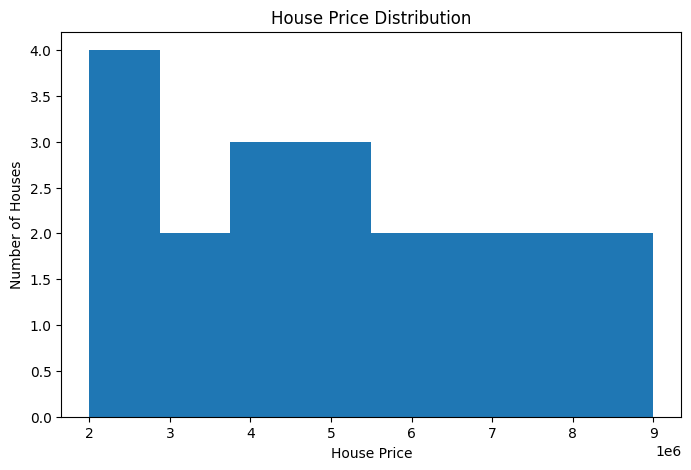

In [11]:
# price distribution
plt.figure(figsize=(8, 5))

plt.hist(df["Price"], bins=8)

plt.title("House Price Distribution")
plt.xlabel("House Price")
plt.ylabel("Number of Houses")

plt.show()

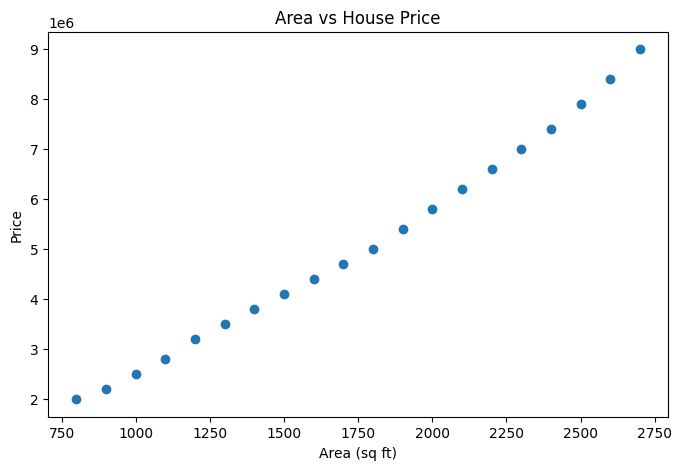

In [12]:
# area vs price
plt.figure(figsize=(8, 5))

plt.scatter(df["Area"], df["Price"])

plt.title("Area vs House Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")

plt.show()

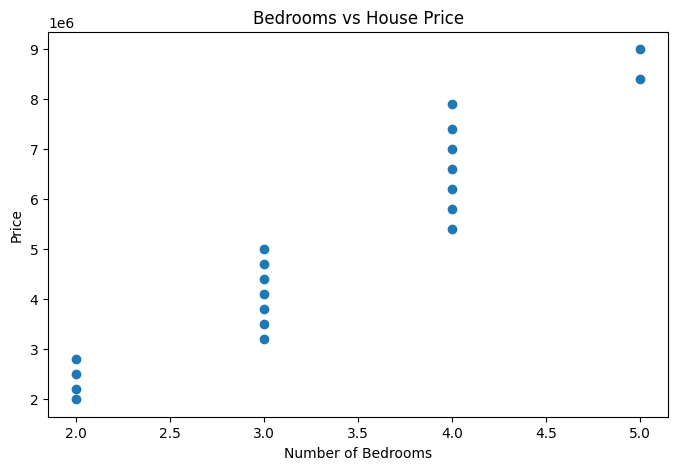

In [13]:
# bedroom vs price
plt.figure(figsize=(8, 5))

plt.scatter(df["Bedrooms"], df["Price"])

plt.title("Bedrooms vs House Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price")

plt.show()

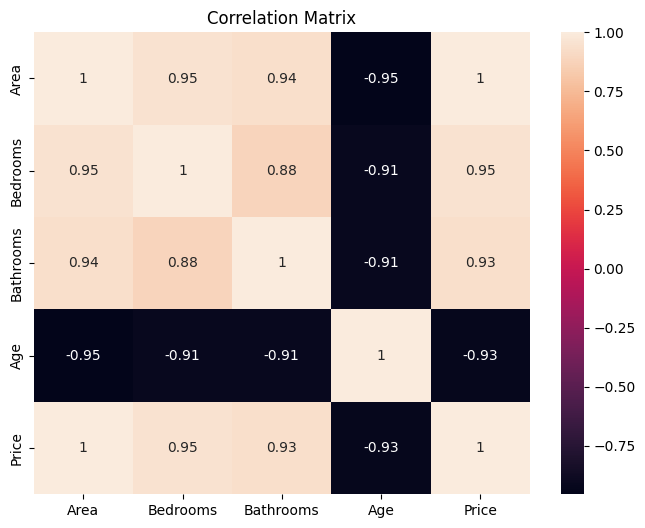

In [14]:
# correlation matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.title("Correlation Matrix")

plt.show()

## 4. Feature Selection

The input features used for prediction are:

- Area
- Bedrooms
- Bathrooms
- Age

The target variable is:

- Price

The Machine Learning model will learn the relationship between these features and house price.

In [15]:
X = df[["Area", "Bedrooms", "Bathrooms", "Age"]]

y = df["Price"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Area  Bedrooms  Bathrooms  Age
0   800         2          1   20
1   900         2          1   18
2  1000         2          2   15
3  1100         2          2   14
4  1200         3          2   12

Target:
0    2000000
1    2200000
2    2500000
3    2800000
4    3200000
Name: Price, dtype: int64


X = Input Features
y = Target / Output

In [16]:
# Split the data

from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 16
Testing records: 4


## 5. Linear Regression

Linear Regression is a supervised Machine Learning algorithm used to predict a continuous numerical value.

In this project, Linear Regression is used to predict the price of a house.

The model learns the relationship between house features and house prices from the training data.

In [22]:
from sklearn.linear_model import LinearRegression

In [31]:
# Create Linear Regression model

model = LinearRegression()

print("Linear Regression model created successfully!")

Linear Regression model created successfully!


In [24]:
# Train the model

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


Area
Bedrooms
Bathrooms
Age
   ↓
Training Data
   ↓
Linear Regression
   ↓
Learned relationship
   ↓
House Price Prediction

In [25]:
# View model coefficients

print("Intercept:", model.intercept_)

print("\nCoefficients:")

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

Intercept: -4339495.815943457

Coefficients:
Area : 4571.317715651938
Bedrooms : 158763.44875317207
Bathrooms : -29435.204798558014
Age : 136633.04041442083


In [26]:
# PREDICTION & EVALUATION

y_pred = model.predict(X_test)

print("Predicted prices:")
print(y_pred)

Predicted prices:
[2338310.8575743  7879377.52983369 7131182.23191628 2522176.54831065]


In [27]:
# Compare actual and predicted prices

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison

,Actual Price,Predicted Price
0,2000000,2.338311e+06
1,7900000,7.879378e+06
2,7000000,7.131182e+06
3,2200000,2.522177e+06


Actual Price
     vs
Predicted Price

In [28]:
# Calculate MAE

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 203073.026991884


What is MAE?

Mean Absolute Error tells us, on average, how far the predicted price is from the actual price.

Smaller MAE is better.

In [29]:
# Calculate MSE

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 58971507220.07895


In [ ]:
# Calculate RMSE

rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

RMSE is expressed in the same unit as the target, so here it is in price units.


In [30]:
# Calculate R² Score

from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9918793001504324


Simple explanation

R² tells us how well the model explains the variation in house prices.

A value closer to 1 generally indicates a better fit.

In [ ]:
# Actual vs Predicted graph

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

example:  

Area = 1800 sq ft
Bedrooms = 3
Bathrooms = 2
Age = 5 years

In [ ]:
# Predict a completely new house

new_house = pd.DataFrame({
    "Area": [1800],
    "Bedrooms": [3],
    "Bathrooms": [2],
    "Age": [5]
})

predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

In [ ]:
# Make another prediction

new_house = pd.DataFrame({
    "Area": [2500],
    "Bedrooms": [4],
    "Bathrooms": [3],
    "Age": [3]
})

predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

<!-- Final conclusion -->
# 6. Conclusion

In this project, we successfully developed a House Price Prediction Machine Learning model using Python and Scikit-learn.

### Work Completed

1. Created and loaded a house price dataset.
2. Explored the dataset.
3. Checked missing values and duplicate records.
4. Performed statistical analysis.
5. Created different visualizations.
6. Selected input features and target variable.
7. Split the dataset into training and testing sets.
8. Created a Linear Regression model.
9. Trained the Machine Learning model.
10. Generated house price predictions.
11. Evaluated the model using MAE, MSE, RMSE, and R² score.
12. Compared actual and predicted prices.
13. Predicted the price of new houses.

### Result

The project demonstrates the complete basic Machine Learning workflow for a regression problem. The trained model can use house characteristics to estimate the price of a new house.
